# **House Sale Price Prediction (High dimensional data Analysis)**
* Creating a model to predict house sales price from high dimensional data.
* Working with data having both numerical and categorical features.
* Dataset contains 82 features.
* Handling with high dimensionality for better performances.

# **Steps involved :**
* Importing data
* Visualizing key features of data
* Droping :
  * Irrelavent features.
  * Features having more null values.
  * Features having less correlation with target variables.
* Splitting data into Train and Test sets
* Imputing null values in Train and Test sets for both
  * Numerical features
  * Categorical

* Encoding Categorical features
  * fit_transforming for train data
  * transforming for test data
* Fitting data to model
* Evaluation with corresponding metrics
* Hyperparameter tunning
* Exporting best estimator

# **Basic Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Importing data**

In [4]:
df = pd.read_excel("housing.xlsx")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# **Inspection**

In [5]:
df.shape

(2930, 82)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

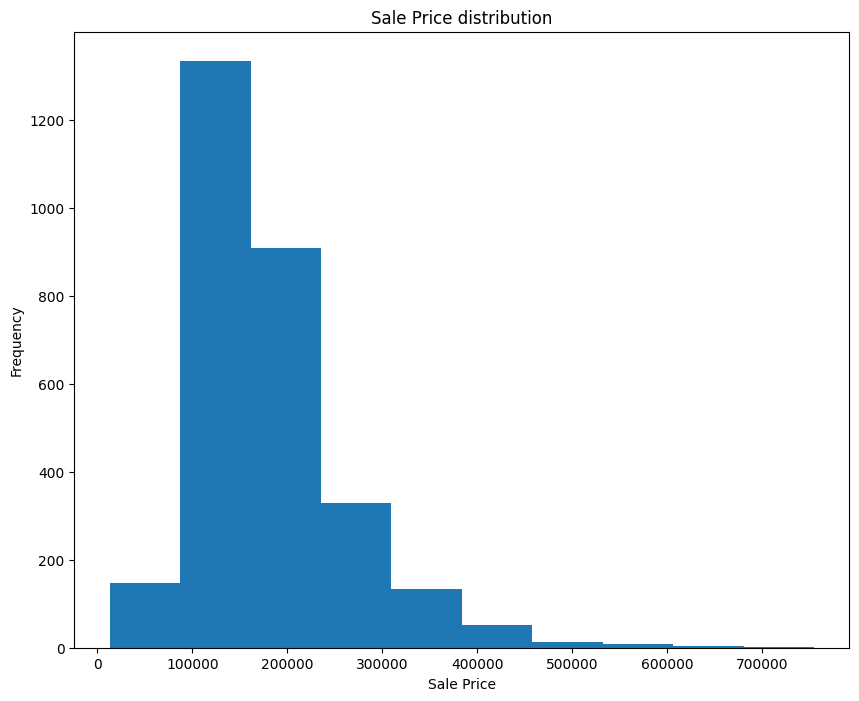

In [7]:
plt.figure(figsize=(10,8))
plt.hist(df["SalePrice"],bins = 10)
plt.title("Sale Price distribution")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

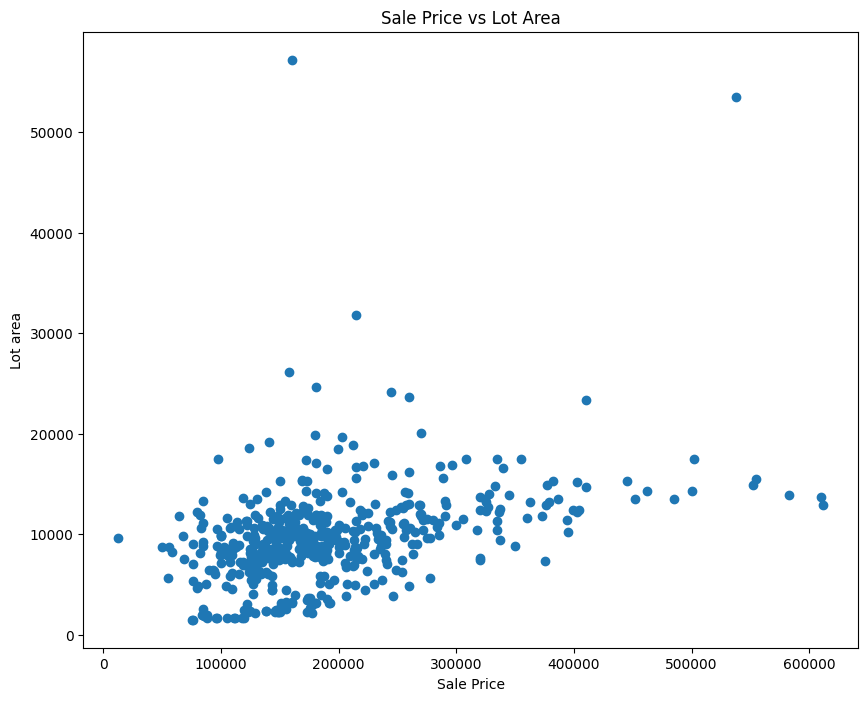

In [8]:
plt.figure(figsize=(10,8))
plt.scatter(df["SalePrice"].head(500),df["Lot Area"].head(500))
plt.title("Sale Price vs Lot Area")
plt.xlabel("Sale Price")
plt.ylabel("Lot area")
plt.show()

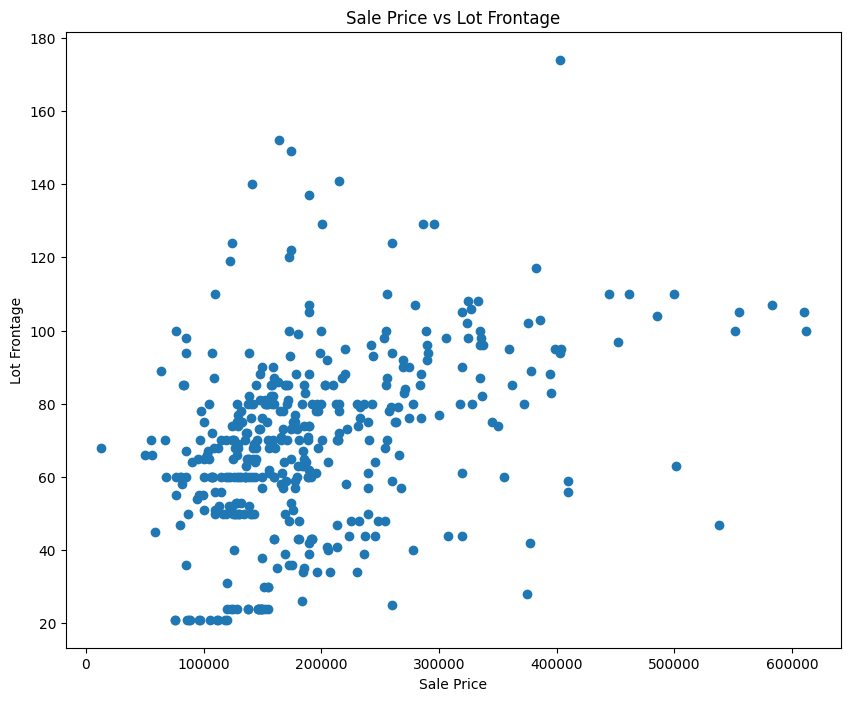

In [9]:
plt.figure(figsize=(10,8))
plt.scatter(df["SalePrice"].head(500),df["Lot Frontage"].head(500))
plt.title("Sale Price vs Lot Frontage")
plt.xlabel("Sale Price")
plt.ylabel("Lot Frontage")
plt.show()

# Droping irrelavent **features**

In [10]:
df = df.drop(["Order","PID"],axis = 1)

# **Droping features having more than 80 % null values bold text**

In [11]:
df.isnull().sum().sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 80, dtype: int64

In [12]:
null_percentages = ((df.isnull().sum()/df.isnull().count())*100).sort_values(ascending=False)
null_percentages

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
                    ...    
Mo Sold            0.000000
Yr Sold            0.000000
Sale Type          0.000000
Sale Condition     0.000000
SalePrice          0.000000
Length: 80, dtype: float64

In [13]:
df = df.drop(["Pool QC","Misc Feature","Alley","Fence"], axis = 1)
df.shape

(2930, 76)

# **Droping least significant features using correlation**

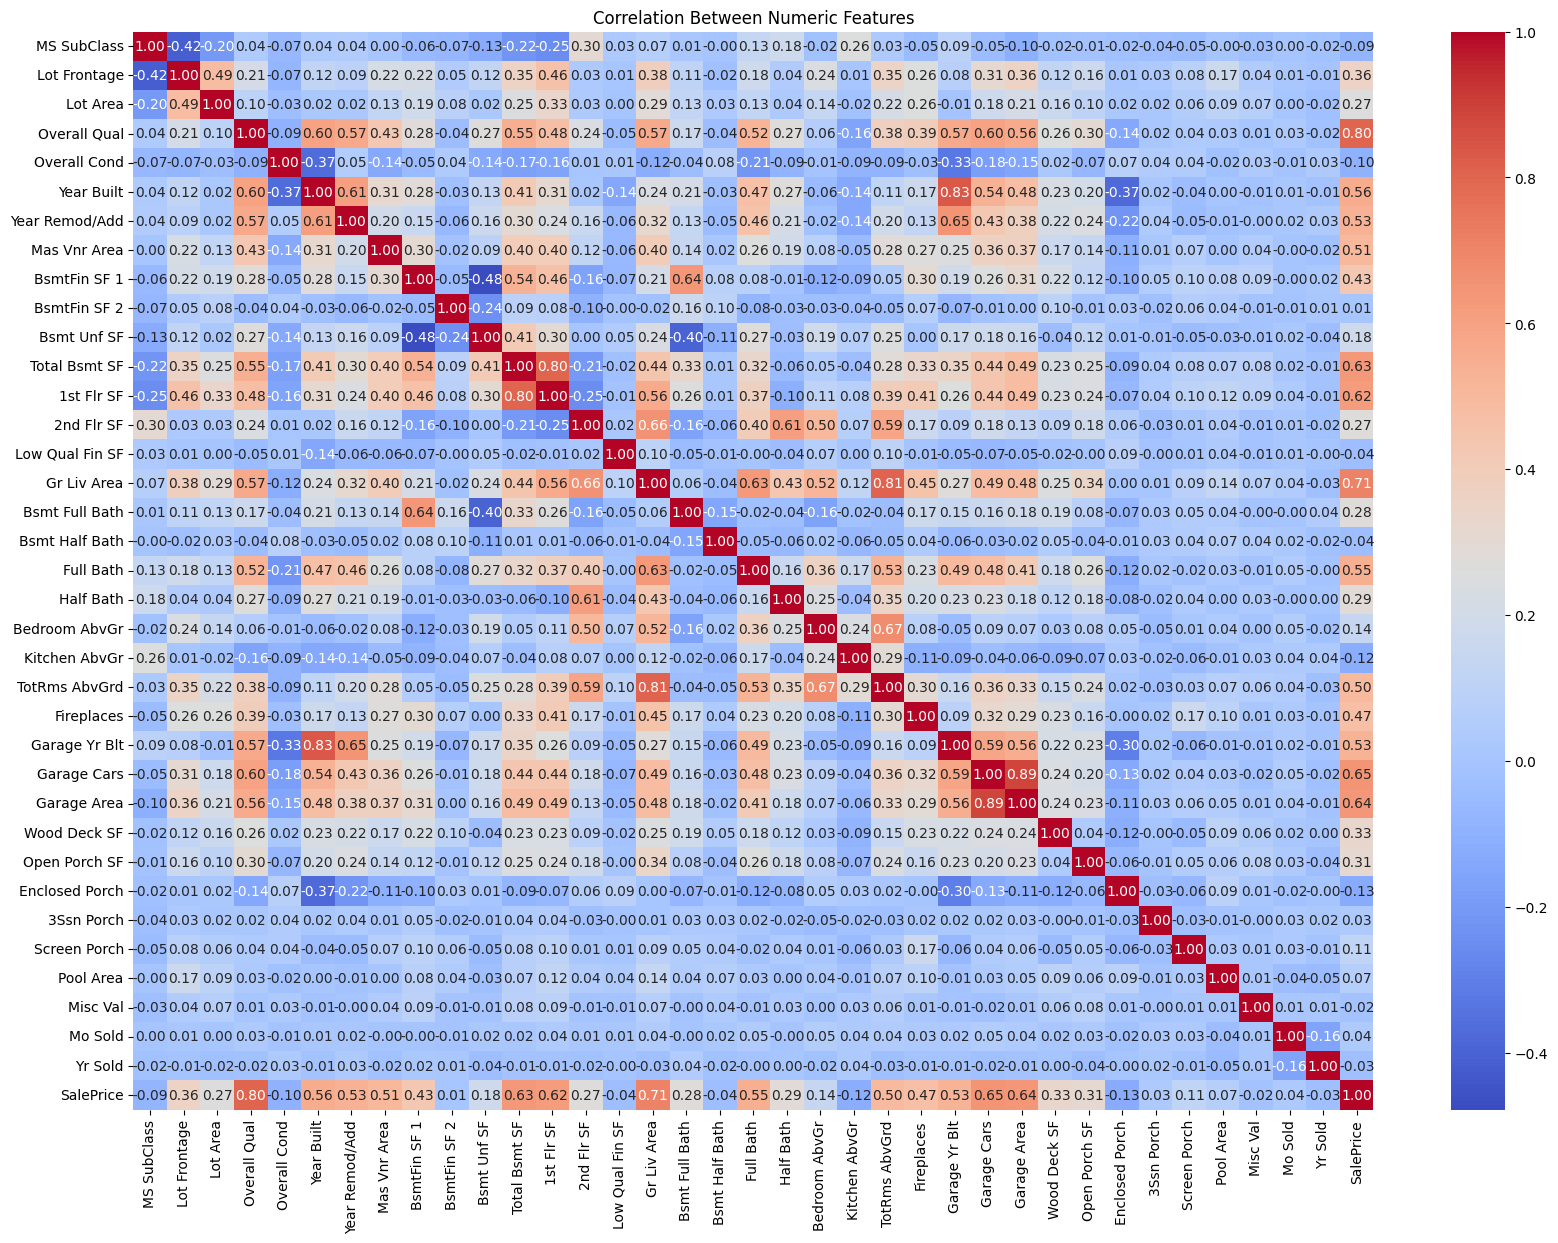

In [14]:
# finding important features using correlation for numerical features

numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

# ploting correlation matrix
plt.figure(figsize=(20, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()


In [15]:
# Droping least significant features
numeric_df = df.select_dtypes(include='number')
categorical_df = df.select_dtypes(exclude='number')

correlation_with_target = numeric_df.corr()['SalePrice'].abs()

relevant_numeric = correlation_with_target[correlation_with_target >= 0.1].index

filtered_df = pd.concat([df[relevant_numeric], categorical_df], axis=1)
filtered_df.shape


(2930, 67)

# **Splitting data into Train and Test splits**

In [16]:
# splitting into train test splits

from sklearn.model_selection import train_test_split
X = filtered_df.drop("SalePrice",axis = 1)
y = filtered_df["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2,random_state= 42)

# **Imputing null values in numerical features**

In [17]:
# filling missing values of X_train (for numerical features) and creating feature "is_filled" with True value.

from sklearn.impute import SimpleImputer

numeric_cols = X_train.select_dtypes(include='number').columns


missing_mask = X_train[numeric_cols].isna()

imputer = SimpleImputer(strategy='mean')
imputed_array = imputer.fit_transform(X_train[numeric_cols])
X_train[numeric_cols] = imputed_array
X_train['is_filled'] = missing_mask.any(axis=1)

X_train.head(3)


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,Total Bsmt SF,...,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition,is_filled
381,80.000000,10400.0,7.0,5.0,1976.0,1976.0,189.0,0.0,1090.0,1090.0,...,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Family,False
834,69.207586,28698.0,5.0,5.0,1967.0,1967.0,0.0,249.0,0.0,1013.0,...,Min2,NaN,Attchd,Fin,TA,TA,Y,WD,Abnorml,True
1898,70.000000,9842.0,4.0,5.0,1962.0,1962.0,0.0,0.0,0.0,0.0,...,Typ,NaN,CarPort,Unf,TA,TA,Y,WD,Normal,False


In [18]:
# filling missing values of X_test (for numerical features) and creating feature "is_filled" with True value.

numeric_cols = X_test.select_dtypes(include='number').columns
missing_mask = X_test[numeric_cols].isna()

imputer = SimpleImputer(strategy='mean')
imputed_array = imputer.fit_transform(X_test[numeric_cols])
X_test[numeric_cols] = imputed_array
X_test['is_filled'] = missing_mask.any(axis=1)

X_test.head(3)

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,Total Bsmt SF,...,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition,is_filled
1357,69.292434,5100.0,8.0,7.0,1925.0,1996.0,0.0,0.0,588.0,588.0,...,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Normal,True
2367,21.000000,1890.0,6.0,7.0,1972.0,1972.0,380.0,282.0,212.0,494.0,...,Typ,NaN,Detchd,Unf,TA,TA,Y,WD,Normal,False
2822,62.000000,7162.0,7.0,5.0,2003.0,2004.0,190.0,0.0,796.0,796.0,...,Typ,Gd,BuiltIn,Fin,TA,TA,Y,WD,Normal,False


# **Imputing Categorical features**

In [19]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

cat_na_mask = X_train[cat_cols].isna().any(axis=1)
X_train['is_filled'] = False

imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = imputer.fit_transform(X_train[cat_cols])
X_train.head(3)

C:\Users\tamma\AppData\Local\Temp\ipykernel_18580\1913413484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,Total Bsmt SF,...,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition,is_filled
381,80.000000,10400.0,7.0,5.0,1976.0,1976.0,189.0,0.0,1090.0,1090.0,...,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Family,False
834,69.207586,28698.0,5.0,5.0,1967.0,1967.0,0.0,249.0,0.0,1013.0,...,Min2,Gd,Attchd,Fin,TA,TA,Y,WD,Abnorml,False
1898,70.000000,9842.0,4.0,5.0,1962.0,1962.0,0.0,0.0,0.0,0.0,...,Typ,Gd,CarPort,Unf,TA,TA,Y,WD,Normal,False


In [20]:

cat_cols = X_test.select_dtypes(include=['object', 'category']).columns

cat_na_mask = X_test[cat_cols].isna().any(axis=1)

X_test['is_filled'] = False

imputer = SimpleImputer(strategy='most_frequent')
X_test[cat_cols] = imputer.fit_transform(X_test[cat_cols])
X_test.loc[cat_na_mask, 'is_filled'] = True
X_test.head(3)


C:\Users\tamma\AppData\Local\Temp\ipykernel_18580\2179928367.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_test.select_dtypes(include=['object', 'category']).columns


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,Total Bsmt SF,...,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition,is_filled
1357,69.292434,5100.0,8.0,7.0,1925.0,1996.0,0.0,0.0,588.0,588.0,...,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Normal,True
2367,21.000000,1890.0,6.0,7.0,1972.0,1972.0,380.0,282.0,212.0,494.0,...,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Normal,True
2822,62.000000,7162.0,7.0,5.0,2003.0,2004.0,190.0,0.0,796.0,796.0,...,Typ,Gd,BuiltIn,Fin,TA,TA,Y,WD,Normal,False


# **Encoding Categorical features of Train split (Fit_transform)**

In [22]:
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

cat_cols = X_train.select_dtypes(include='object').columns

X_train_encoded = X_train.copy()

for col in cat_cols:
    unique_vals = X_train[col].nunique()

    if unique_vals < 5:
        # Label Encoding
        le = LabelEncoder()
        X_train_encoded[col] = le.fit_transform(X_train[col])
    else:
        # Target Encoding using the 'target' column
        target_encoder = ce.TargetEncoder(cols=[col])
        X_train_encoded[col] = target_encoder.fit_transform(X_train[col], y_train)
X_train_encoded.head(3)

C:\Users\tamma\AppData\Local\Temp\ipykernel_18580\537138981.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,Total Bsmt SF,...,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition,is_filled
381,80.000000,10400.0,7.0,5.0,1976.0,1976.0,189.0,0.0,1090.0,1090.0,...,181024.453504,202854.910973,192653.308504,1,180902.677652,180945.563387,2,173097.8348,154955.987433,False
834,69.207586,28698.0,5.0,5.0,1967.0,1967.0,0.0,249.0,0.0,1013.0,...,147963.961603,169388.737239,192653.308504,0,180902.677652,180945.563387,2,173097.8348,139819.583672,False
1898,70.000000,9842.0,4.0,5.0,1962.0,1962.0,0.0,0.0,0.0,0.0,...,181024.453504,169388.737239,158518.341924,2,180902.677652,180945.563387,2,173097.8348,174544.577755,False


# **Encoding Categorical features of Train split (transform)**

In [23]:
X_test_encoded = X_test.copy()

for col in cat_cols:
    unique_vals = X_test[col].nunique()

    if unique_vals < 5:
        le = LabelEncoder()
        le.fit(X_train[col])
        X_test_encoded[col] = le.transform(X_test[col])
    else:
        target_encoder = ce.TargetEncoder(cols=[col])
        target_encoder.fit(X_train[col], y_train)
        X_test_encoded[col] = target_encoder.transform(X_test[col])

X_test_encoded.head(3)



,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,Total Bsmt SF,...,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition,is_filled
1357,69.292434,5100.0,8.0,7.0,1925.0,1996.0,0.0,0.0,588.0,588.0,...,181024.453504,169388.737239,132925.828843,2,4,4,2,173097.8348,174544.577755,True
2367,21.000000,1890.0,6.0,7.0,1972.0,1972.0,380.0,282.0,212.0,494.0,...,181024.453504,169388.737239,132925.828843,2,4,4,2,173097.8348,174544.577755,True
2822,62.000000,7162.0,7.0,5.0,2003.0,2004.0,190.0,0.0,796.0,796.0,...,181024.453504,169388.737239,246470.461543,0,4,4,2,173097.8348,174544.577755,False


# **Fitting encoded data to model**

In [24]:
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor(n_jobs= -1)
reg.fit(X_train_encoded , y_train)
y_preds = reg.predict(X_test_encoded)

# **Evaluation of differnet metrics**

In [25]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

r_squared_score = r2_score(y_test , y_preds)
mae = mean_absolute_error(y_test , y_preds)
mse = mean_squared_error(y_test, y_preds)

In [26]:
print(f"R squared score :{r_squared_score}")
print(f"Mean absolute error:{mae}")
print(f"Mean squared error:{mse}")

R squared score :0.9012943943897792
Mean absolute error:17143.455887372013
Mean squared error:791376924.0292233
